In [1]:
import yfinance as yf
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
stocks = ["AMZN", "MSFT", "GOOG"]  # List of stock tickers
#start = dt.datetime.today() - dt.timedelta(360) # 30 days ago
#end = dt.datetime.today()

ohlcv_data = {}  # Dictionary to hold OHLCV data. Key-Value pair: Ticker-DataFrame

# get closing prices for each stock
for ticker in stocks:
    temp = yf.download(ticker, period="1y", interval="1d")
    temp.dropna(how="any", inplace=True) # type: ignore
    ohlcv_data[ticker] = temp

#df = ohlcv_data["AMZN"]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


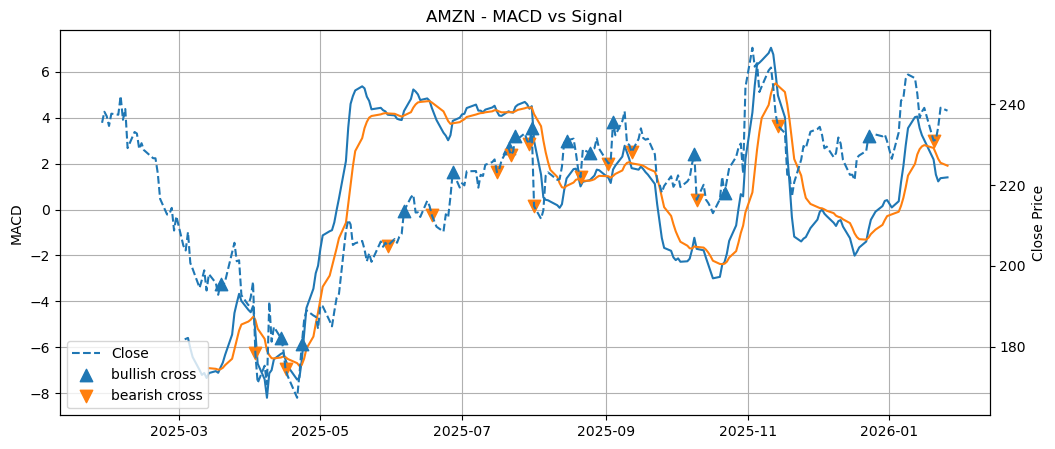

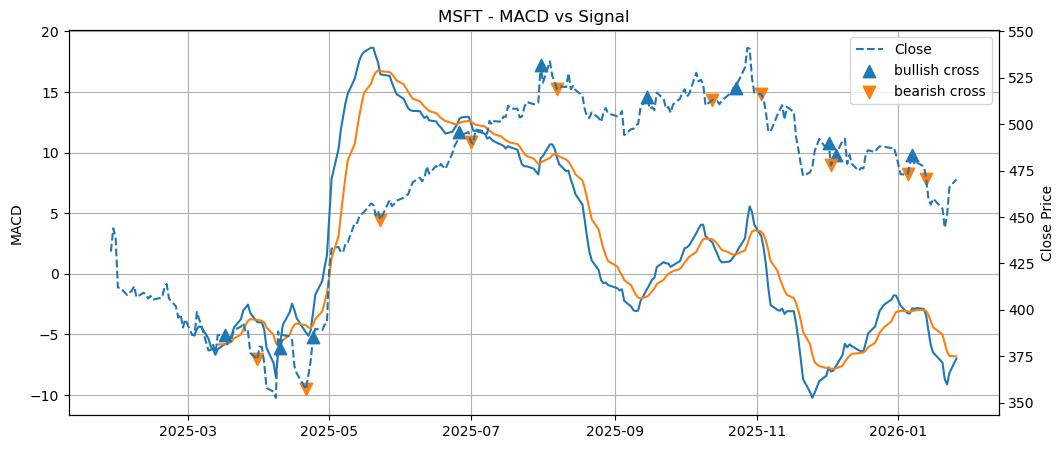

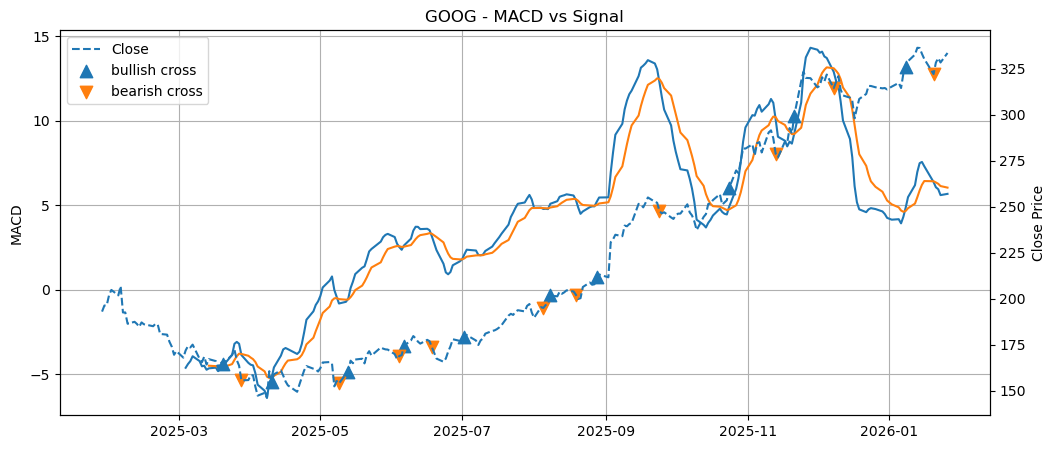

In [3]:
# macd function, 
def macd(DF, a=12, b=26, c=9): # default values
    df = DF.copy()
    df["ma_fast"] = df["Close"].ewm(span=a, min_periods=a).mean()
    df["ma_slow"] = df["Close"].ewm(span=b, min_periods=b).mean()

    df["macd"] = df["ma_fast"] - df["ma_slow"]

    df["signal"] = df["macd"].ewm(span=c, min_periods=c).mean()

    return df.loc[:, ["macd", "signal"]]

for ticker in ohlcv_data:
    ohlcv_data[ticker][["MACD", "SIGNAL"]] = macd(ohlcv_data[ticker])

# simple moving avg could be done by
# df["ma"] = df["Close"].rolling(a).mean()

# plotting macd line and signal line on each stock

for ticker in ohlcv_data:
    df = ohlcv_data[ticker].copy()

    # crossover signals
    df["diff"] = df["MACD"] - df["SIGNAL"]
    df["bullish"] = (df["diff"] > 0) & (df["diff"].shift(1) <= 0) # macd cross signal from above, bullish signal. BUY
    df["bearish"] = (df["diff"] < 0) & (df["diff"].shift(1) >= 0) # macd cross signal from below, bearish signal. SELL

    fig, ax1 = plt.subplots(figsize=(12, 5))
    # MACD + SIGNAL
    ax1.plot(df.index, df["MACD"], label="MACD")
    ax1.plot(df.index, df["SIGNAL"], label="Signal")  
    ax1.set_ylabel("MACD") 
    ax1.grid(True) 

    # Close price
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["Close"], label="Close", linestyle="--")
    ax2.set_ylabel("Close Price")

    # adding signal markers
    bull_idx = df.index[df["bullish"]]
    bear_idx = df.index[df["bearish"]]

    ax2.scatter(bull_idx, df.loc[bull_idx, "Close"], marker="^", s=80, label="bullish cross")
    ax2.scatter(bear_idx, df.loc[bear_idx, "Close"], marker="v", s=80, label="bearish cross")
    
    plt.title(f"{ticker} - MACD vs Signal")

    plt.legend()
    plt.show()

    